# Paper Trading Analysis — Market Maker Strategy

Loads CSV output from `bun run src/paper-trade.ts` and analyzes:
1. **Fair value model** — Does our Phi(z) track market prices? Where does it diverge?
2. **Quote behavior** — Spread, requote frequency, time-based adjustments
3. **Fill simulation** — When/where do fills happen, at what prices vs fair value
4. **Resolution P&L** — What would have happened with actual market outcomes
5. **Inventory dynamics** — Net exposure over time, skew effectiveness

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.stats import norm
import json, requests, warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

PAPER_DIR = Path("data/paper")

# Auto-detect most recent session files
def latest_file(pattern: str) -> Path:
    files = sorted(PAPER_DIR.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files matching {pattern} in {PAPER_DIR}")
    return files[0]

ticks_path = latest_file("ticks_*.csv")
trades_path = latest_file("trades_*.csv")
markets_path = latest_file("markets_*.csv")

print(f"Ticks:   {ticks_path.name}")
print(f"Trades:  {trades_path.name}")
print(f"Markets: {markets_path.name}")

Ticks:   ticks_2026-03-05T1822.csv
Trades:  trades_2026-03-05T1822.csv
Markets: markets_2026-03-05T1822.csv


In [2]:
# ── Load data ──

ticks = pd.read_csv(ticks_path)
trades = pd.read_csv(trades_path)
markets = pd.read_csv(markets_path)

# Parse timestamps
ticks["dt"] = pd.to_datetime(ticks["timestamp"], unit="ms")
trades["dt"] = pd.to_datetime(trades["timestamp"], unit="ms")

# Coerce numeric columns that may have empty strings
for col in ["btc_return_pct", "realized_vol_pct", "fair_up", "fair_down", "z_score",
            "up_mid", "down_mid", "up_spread", "down_spread"]:
    if col in ticks.columns:
        ticks[col] = pd.to_numeric(ticks[col], errors="coerce")

for col in ["price", "size", "fill_price", "fill_size", "position_after",
            "avg_entry_after", "realized_pnl", "btc_price", "fair_value", "time_remaining_s"]:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

print(f"Ticks:   {len(ticks):,} rows across {ticks['market_slug'].nunique()} markets")
print(f"Trades:  {len(trades):,} rows")
print(f"Markets: {len(markets):,} rows")
display(markets[["market_slug", "btc_open", "btc_close", "btc_return_pct",
                  "total_orders", "total_fills", "resolution_winner", "total_pnl"]])

Ticks:   1,304 rows across 5 markets
Trades:  7,247 rows
Markets: 5 rows


,market_slug,btc_open,btc_close,btc_return_pct,total_orders,total_fills,resolution_winner,total_pnl
0,btc-updown-5m-1772734800,NaN,70847.08,NaN,294,6,Down,0.0000
1,btc-updown-5m-1772735100,70868.67,70818.86,-0.070271,882,107,Down,13.1500
2,btc-updown-5m-1772735400,70817.99,70978.48,0.226609,605,61,Up,5.1446
3,btc-updown-5m-1772735700,70981.42,70900.01,-0.114706,1186,150,Down,28.6429
4,btc-updown-5m-1772736000,70908.13,70950.58,0.059866,735,54,pending,8.1000


## 1. Fair Value Model vs Market Price

Does our `P(Up) = Phi(z)` model track the actual market mid price?
- **Blue**: market mid price for the Up token
- **Orange**: our model's fair value estimate
- Divergence = potential edge (or model error)

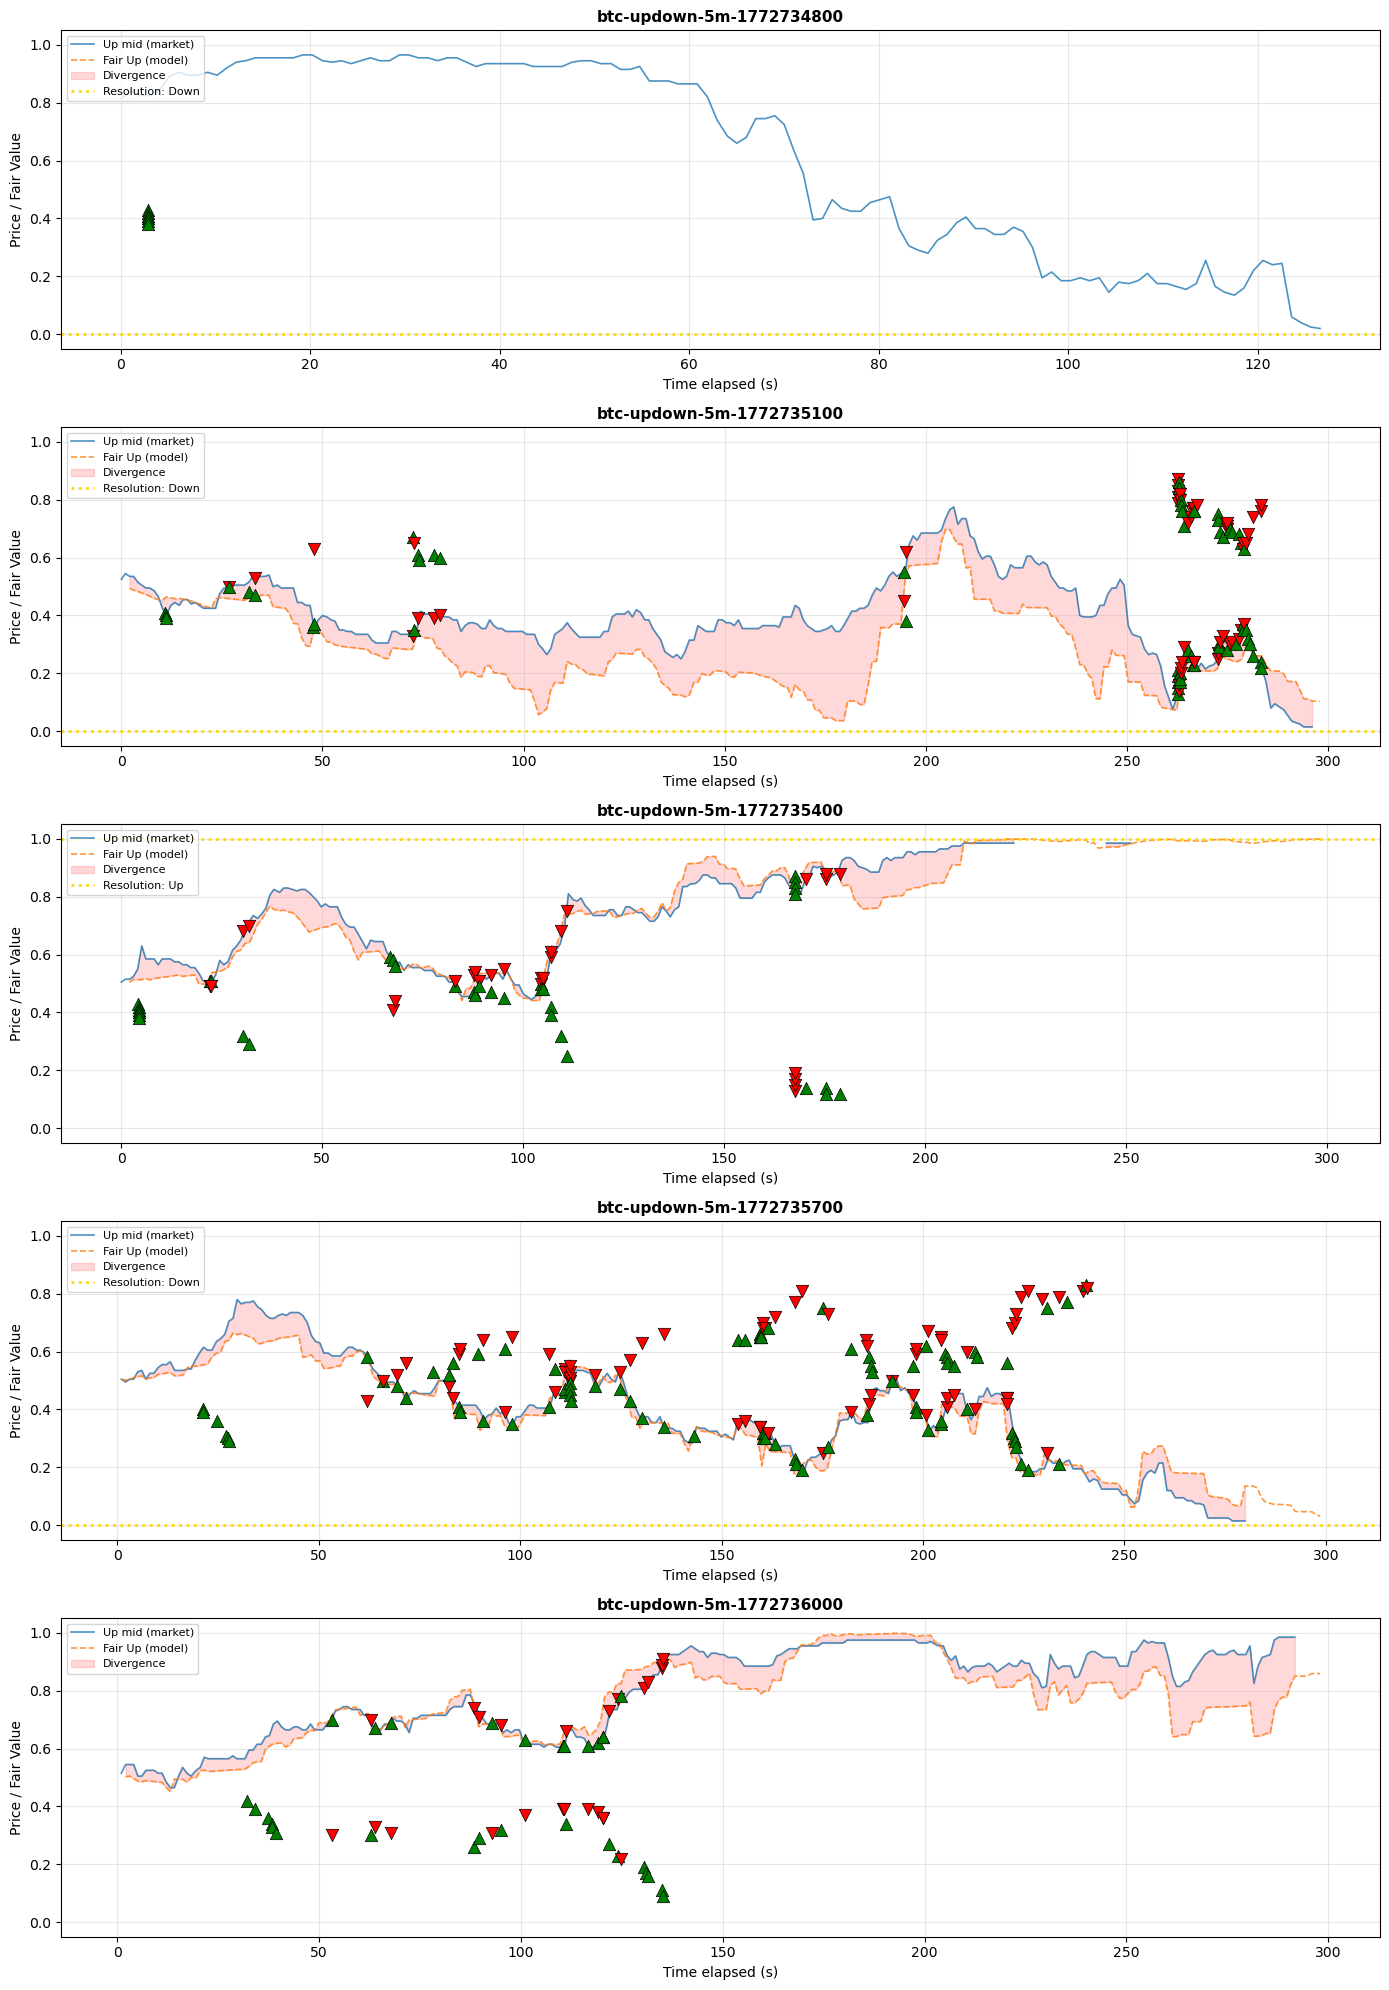

In [3]:
slugs = ticks["market_slug"].unique()
n_markets = len(slugs)
fig, axes = plt.subplots(n_markets, 1, figsize=(14, 4 * n_markets), squeeze=False)

for i, slug in enumerate(slugs):
    ax = axes[i, 0]
    t = ticks[ticks["market_slug"] == slug].copy()
    elapsed = t["time_elapsed_s"].values

    ax.plot(elapsed, t["up_mid"], label="Up mid (market)", alpha=0.8, lw=1.2)
    ax.plot(elapsed, t["fair_up"], label="Fair Up (model)", alpha=0.8, lw=1.2, ls="--")
    ax.fill_between(elapsed, t["up_mid"], t["fair_up"], alpha=0.15, color="red", label="Divergence")

    # Mark fills — convert time_remaining_s to time_elapsed_s for consistent x-axis
    mkt_row = markets[markets["market_slug"] == slug]
    mkt_duration_s = t["time_elapsed_s"].max() + t["time_remaining_s"].min() if len(t) > 0 else 300
    slug_fills = trades[(trades["market_slug"] == slug) & (trades["event_type"] == "FILL")]
    for _, f in slug_fills.iterrows():
        fill_elapsed = mkt_duration_s - f["time_remaining_s"]
        color = "green" if f["side"] == "BUY" else "red"
        marker = "^" if f["side"] == "BUY" else "v"
        ax.scatter(fill_elapsed, f["fill_price"], color=color,
                   marker=marker, s=80, zorder=5, edgecolors="black", lw=0.5)

    # Resolution line
    if len(mkt_row) > 0 and mkt_row.iloc[0]["resolution_winner"] not in ["pending", ""]:
        winner = mkt_row.iloc[0]["resolution_winner"]
        ax.axhline(1.0 if winner == "Up" else 0.0, color="gold", ls=":", lw=2, label=f"Resolution: {winner}")

    ax.set_title(slug, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time elapsed (s)")
    ax.set_ylabel("Price / Fair Value")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 2. BTC Price, Volatility, and Z-Score

The model's inputs over time. Volatility should stabilize after ~30s of Binance ticks.
Z-score drives fair value: positive z → Up likely, negative z → Down likely.

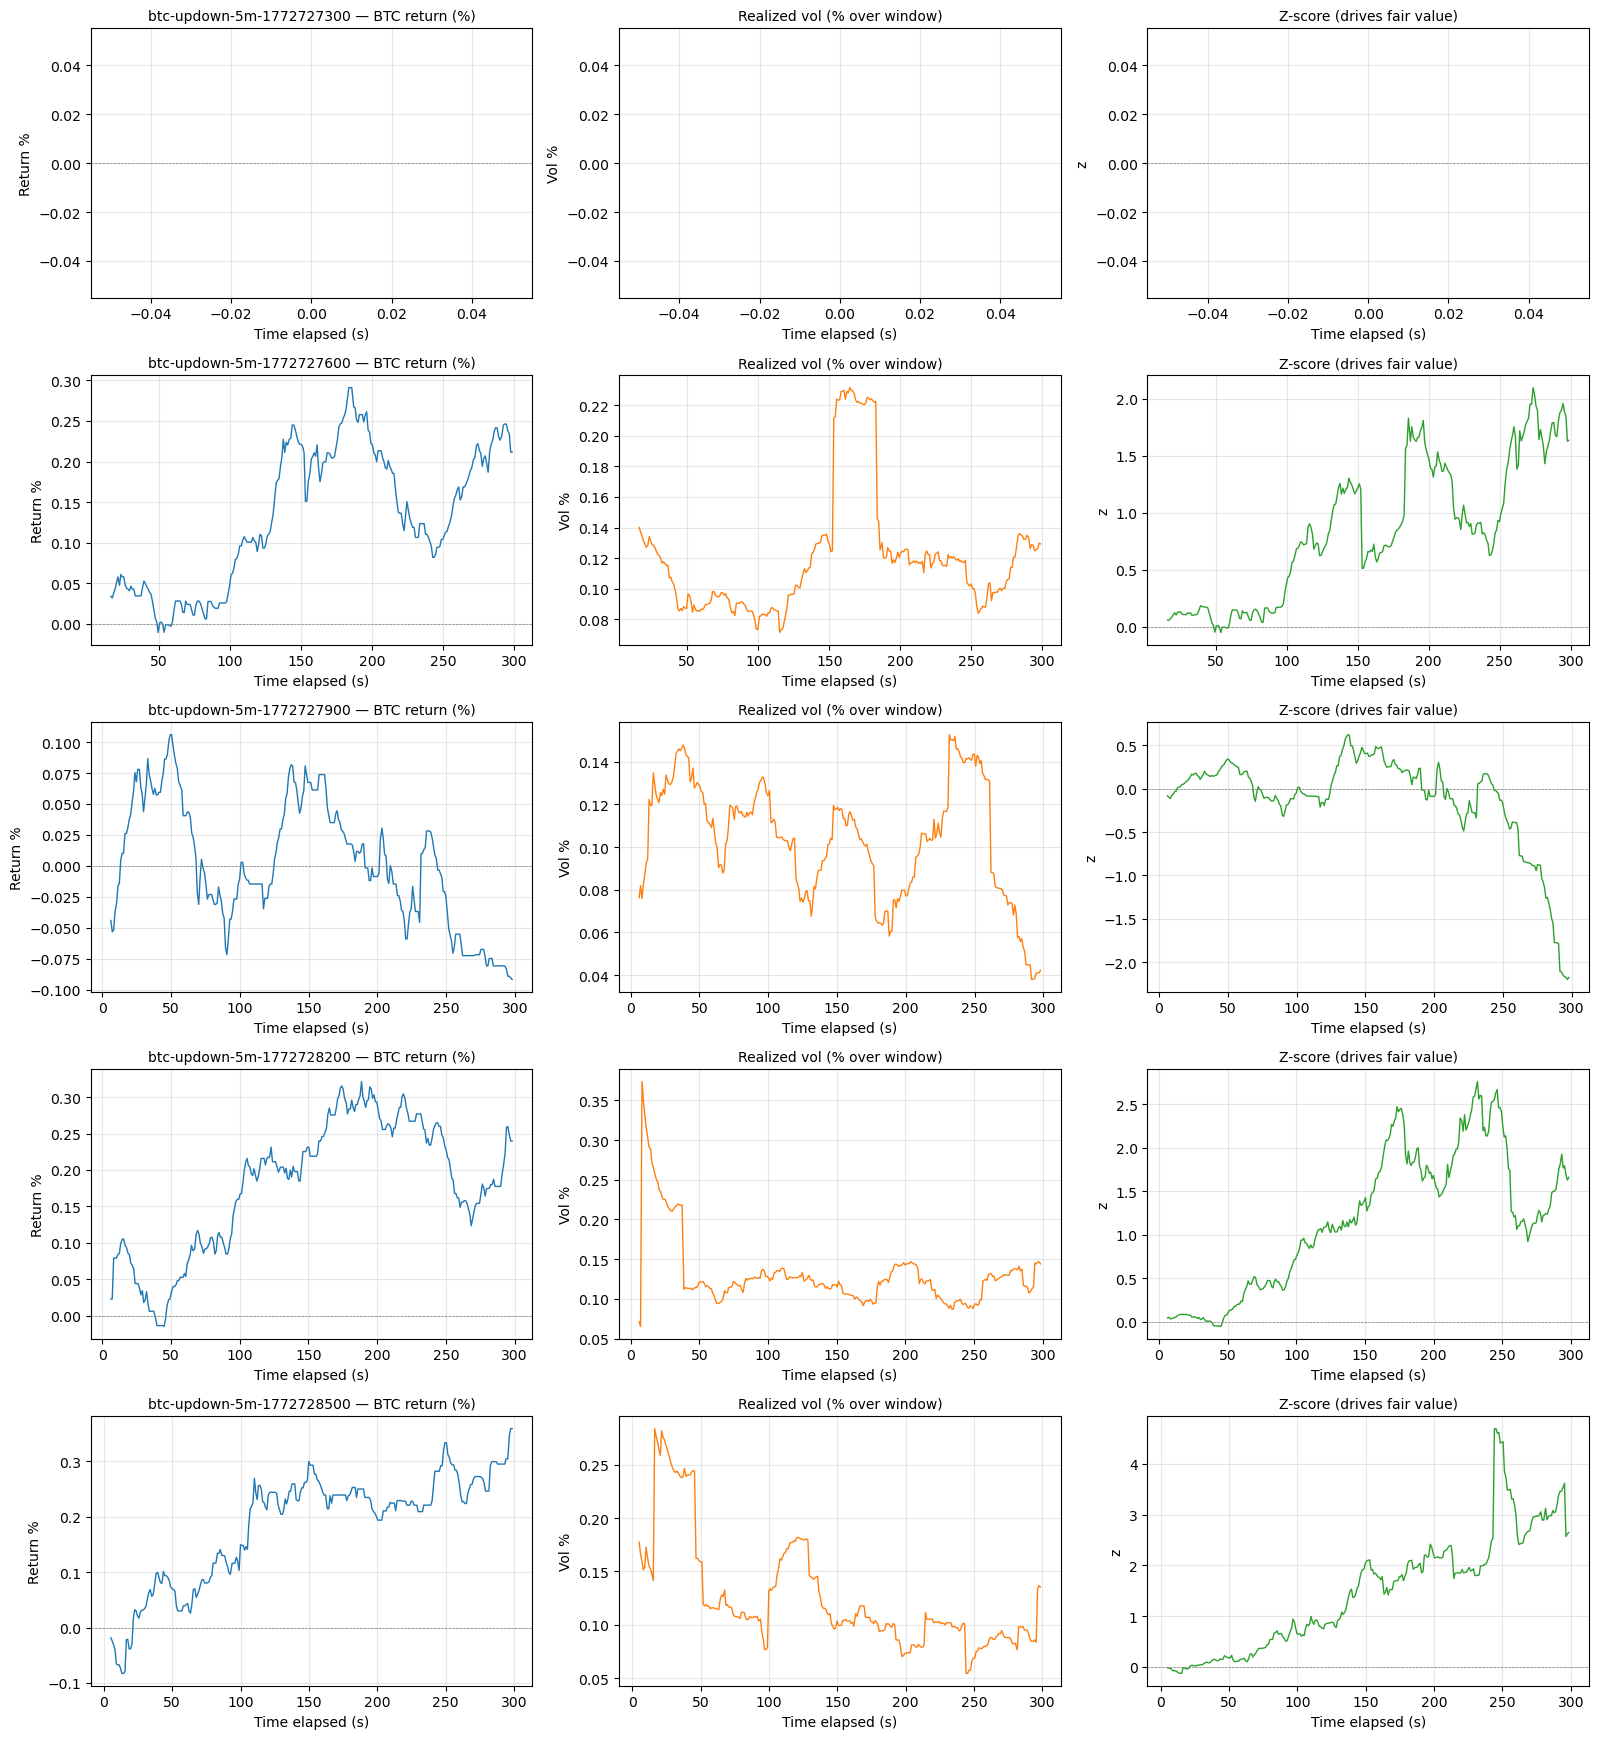

In [4]:
fig, axes = plt.subplots(n_markets, 3, figsize=(16, 3.5 * n_markets), squeeze=False)

for i, slug in enumerate(slugs):
    t = ticks[ticks["market_slug"] == slug].copy()
    elapsed = t["time_elapsed_s"].values

    # BTC price (normalized to return from open)
    axes[i, 0].plot(elapsed, t["btc_return_pct"], color="tab:blue", lw=1)
    axes[i, 0].axhline(0, color="gray", ls="--", lw=0.5)
    axes[i, 0].set_title(f"{slug} — BTC return (%)", fontsize=10)
    axes[i, 0].set_ylabel("Return %")

    # Realized vol
    axes[i, 1].plot(elapsed, t["realized_vol_pct"], color="tab:orange", lw=1)
    axes[i, 1].set_title(f"Realized vol (% over window)", fontsize=10)
    axes[i, 1].set_ylabel("Vol %")

    # Z-score
    axes[i, 2].plot(elapsed, t["z_score"], color="tab:green", lw=1)
    axes[i, 2].axhline(0, color="gray", ls="--", lw=0.5)
    axes[i, 2].set_title(f"Z-score (drives fair value)", fontsize=10)
    axes[i, 2].set_ylabel("z")

    for ax in axes[i, :]:
        ax.set_xlabel("Time elapsed (s)")

plt.tight_layout()
plt.show()

## 3. Trade Activity and Fill Analysis

Where in the market window do fills cluster? What's the edge (fair value - fill price) at fill time?

Total orders placed: 3702
Total fills:         378
Total cancels:       3167
Fill rate:           10.2%

Edge at fill (model fair value vs fill price):
token_label side  fill_price  fair_value    edge  time_remaining_s
       Down  BUY        0.43         NaN     NaN             129.1
       Down  BUY        0.42         NaN     NaN             129.1
       Down  BUY        0.41         NaN     NaN             129.1
       Down  BUY        0.40         NaN     NaN             129.1
       Down  BUY        0.39         NaN     NaN             129.1
       Down  BUY        0.38         NaN     NaN             129.1
         Up  BUY        0.41      0.4559  0.0459             288.1
         Up  BUY        0.40      0.4646  0.0646             287.7
         Up  BUY        0.39      0.4646  0.0746             287.7
         Up SELL        0.50      0.4582  0.0418             272.1
       Down  BUY        0.50      0.5418  0.0418             272.1
       Down  BUY        0.48      0.5396  0.

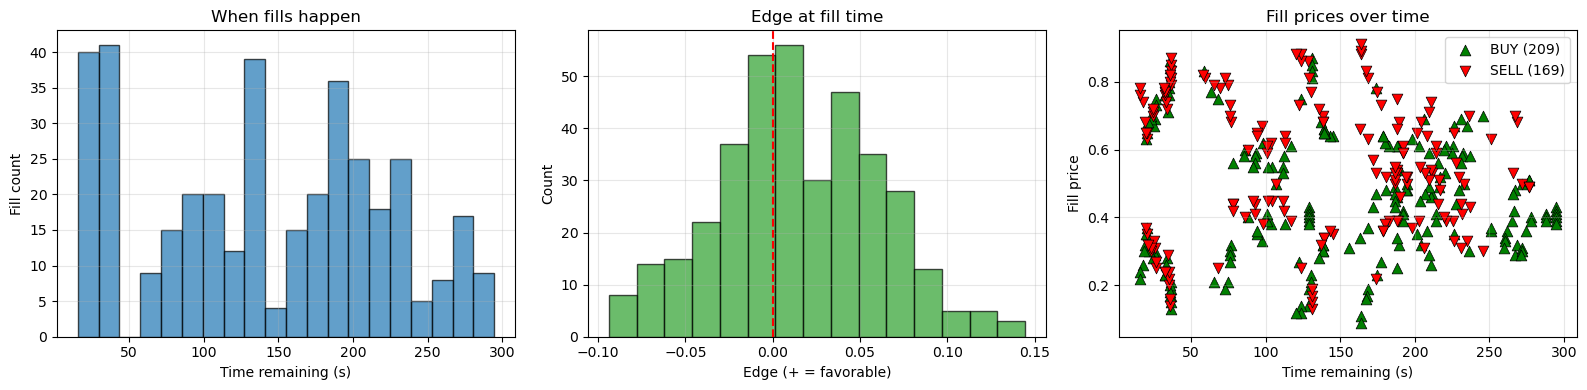

In [4]:
fills = trades[trades["event_type"] == "FILL"].copy()
places = trades[trades["event_type"] == "PLACE"].copy()
cancels = trades[trades["event_type"].isin(["CANCEL", "CANCEL_ALL"])].copy()

print(f"Total orders placed: {len(places)}")
print(f"Total fills:         {len(fills)}")
print(f"Total cancels:       {len(cancels)}")
print(f"Fill rate:           {len(fills) / max(len(places), 1) * 100:.1f}%")

if len(fills) > 0:
    # Edge at fill: for BUY fills, edge = fair_value - fill_price (positive = good)
    # For SELL fills, edge = fill_price - fair_value (positive = good)
    fills["edge"] = np.where(
        fills["side"] == "BUY",
        fills["fair_value"] - fills["fill_price"],
        fills["fill_price"] - fills["fair_value"],
    )

    print(f"\nEdge at fill (model fair value vs fill price):")
    print(fills[["token_label", "side", "fill_price", "fair_value", "edge", "time_remaining_s"]].to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Fill timing histogram
    axes[0].hist(fills["time_remaining_s"], bins=20, edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Time remaining (s)")
    axes[0].set_ylabel("Fill count")
    axes[0].set_title("When fills happen")

    # Edge distribution
    if fills["edge"].notna().any():
        axes[1].hist(fills["edge"], bins=15, edgecolor="black", alpha=0.7, color="tab:green")
        axes[1].axvline(0, color="red", ls="--")
        axes[1].set_xlabel("Edge (+ = favorable)")
        axes[1].set_ylabel("Count")
        axes[1].set_title("Edge at fill time")

    # Fill prices by side
    buy_fills = fills[fills["side"] == "BUY"]
    sell_fills = fills[fills["side"] == "SELL"]
    axes[2].scatter(buy_fills["time_remaining_s"], buy_fills["fill_price"],
                    c="green", marker="^", s=60, label=f"BUY ({len(buy_fills)})", edgecolors="black", lw=0.5)
    axes[2].scatter(sell_fills["time_remaining_s"], sell_fills["fill_price"],
                    c="red", marker="v", s=60, label=f"SELL ({len(sell_fills)})", edgecolors="black", lw=0.5)
    axes[2].set_xlabel("Time remaining (s)")
    axes[2].set_ylabel("Fill price")
    axes[2].set_title("Fill prices over time")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("\nNo fills recorded — strategy may not have had enough vol data to quote.")

## 4. Inventory Dynamics

Net inventory (Up position - Down position) over time. The inventory skew should push
quotes to rebalance — if we're long Up, our Up bid should drop (discourage more buying)
and Up ask should drop (encourage selling).

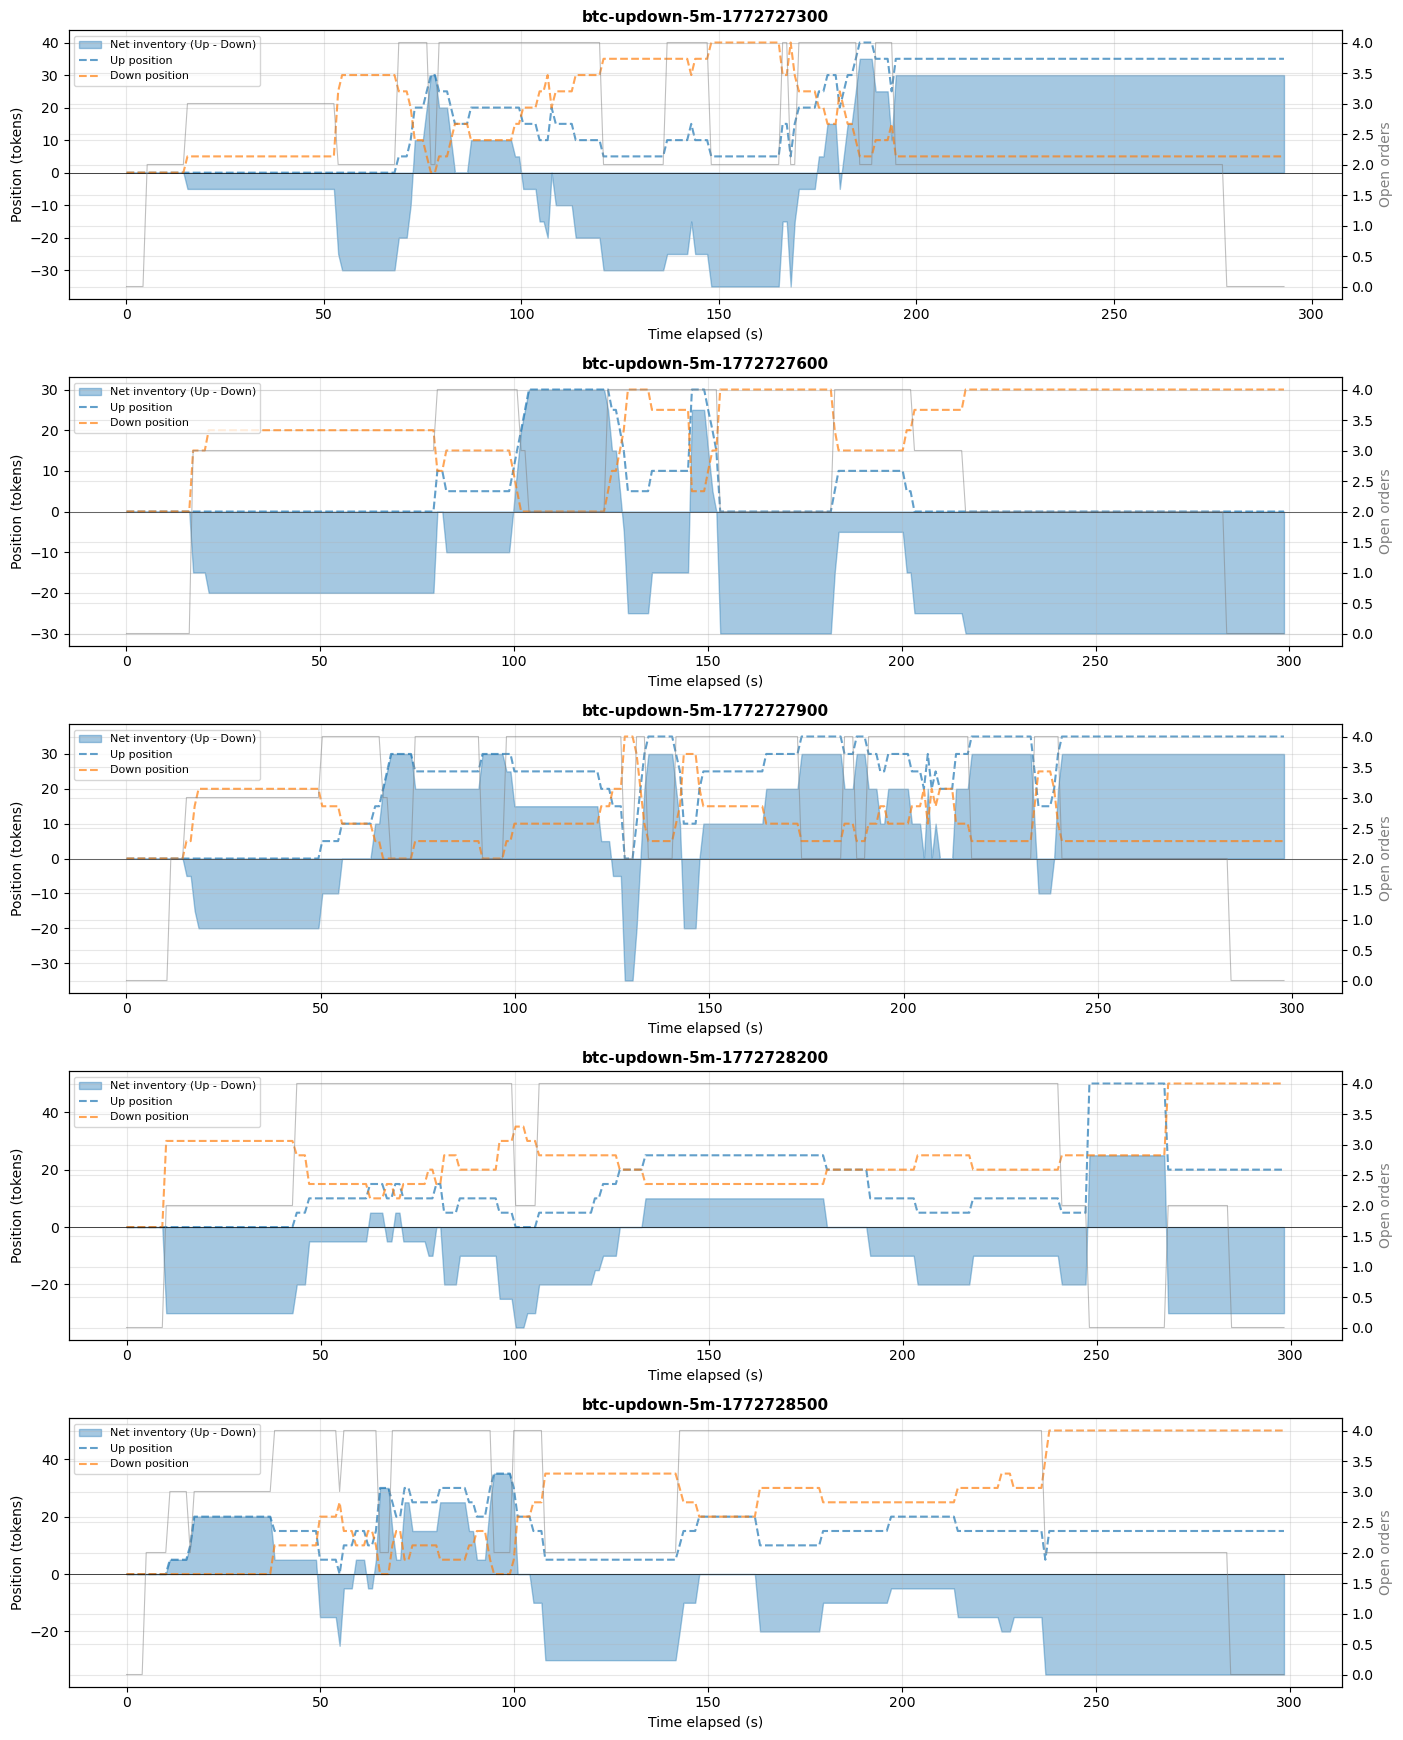

In [6]:
fig, axes = plt.subplots(n_markets, 1, figsize=(14, 3.5 * n_markets), squeeze=False)

for i, slug in enumerate(slugs):
    ax = axes[i, 0]
    t = ticks[ticks["market_slug"] == slug].copy()
    elapsed = t["time_elapsed_s"].values

    ax.fill_between(elapsed, 0, t["net_inventory"], alpha=0.4,
                    color="tab:blue", label="Net inventory (Up - Down)")
    ax.plot(elapsed, t["up_position"], label="Up position", ls="--", alpha=0.7)
    ax.plot(elapsed, t["down_position"], label="Down position", ls="--", alpha=0.7)

    ax2 = ax.twinx()
    ax2.plot(elapsed, t["open_order_count"], color="gray", alpha=0.5, lw=0.8, label="Open orders")
    ax2.set_ylabel("Open orders", color="gray")

    ax.set_title(slug, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time elapsed (s)")
    ax.set_ylabel("Position (tokens)")
    ax.legend(loc="upper left", fontsize=8)
    ax.axhline(0, color="black", lw=0.5)

plt.tight_layout()
plt.show()

## 5. Resolution P&L

Fetch actual market resolutions from the Gamma API and compute what our held positions
would have been worth. This is the key question: does spread capture outweigh resolution losses?

In [5]:
GAMMA_API = "https://gamma-api.polymarket.com"

def fetch_resolution(slug: str) -> dict | None:
    """Fetch resolution from Gamma API. Returns {winner_label, winning_token_id} or None."""
    try:
        resp = requests.get(f"{GAMMA_API}/markets/slug/{slug}", timeout=10)
        if resp.status_code != 200:
            return None
        data = resp.json()
        if data.get("umaResolutionStatus") != "resolved":
            return None
        token_ids = json.loads(data["clobTokenIds"])
        outcomes = json.loads(data["outcomes"])
        outcome_prices = json.loads(data["outcomePrices"])
        winning_idx = next(i for i, p in enumerate(outcome_prices) if float(p) == 1.0)
        return {
            "winner_label": outcomes[winning_idx],
            "winning_token_id": token_ids[winning_idx],
        }
    except Exception as e:
        print(f"  Failed to fetch {slug}: {e}")
        return None

# Fetch resolutions for all traded markets
resolutions = {}
for slug in markets["market_slug"]:
    res = fetch_resolution(slug)
    resolutions[slug] = res
    status = f"{res['winner_label']}" if res else "pending"
    print(f"  {slug}: {status}")

  btc-updown-5m-1772734800: Down
  btc-updown-5m-1772735100: Down
  btc-updown-5m-1772735400: Up
  btc-updown-5m-1772735700: Down
  btc-updown-5m-1772736000: Up


In [6]:
# Reconstruct per-market positions at close from trade log, then compute resolution PnL

def compute_resolution_pnl(slug: str, resolution: dict | None) -> dict:
    """Replay fills for a market and compute final position + resolution PnL."""
    mkt_trades = trades[(trades["market_slug"] == slug) & (trades["event_type"] == "FILL")].copy()
    mkt_info = markets[markets["market_slug"] == slug].iloc[0]

    # Rebuild positions from fills
    positions = {}  # asset_id -> {size, avg_entry, realized_pnl}
    for _, fill in mkt_trades.iterrows():
        aid = fill["asset_id"]
        if aid not in positions:
            positions[aid] = {"size": 0.0, "avg_entry": 0.0, "realized_pnl": 0.0}
        pos = positions[aid]

        if fill["side"] == "BUY":
            total_cost = pos["avg_entry"] * pos["size"] + fill["fill_price"] * fill["fill_size"]
            pos["size"] += fill["fill_size"]
            pos["avg_entry"] = total_cost / pos["size"] if pos["size"] > 0 else 0
        else:
            sell_size = min(fill["fill_size"], pos["size"])
            pnl = (fill["fill_price"] - pos["avg_entry"]) * sell_size
            pos["realized_pnl"] += pnl
            pos["size"] -= sell_size

    # Trading PnL (from sells)
    trading_pnl = sum(p["realized_pnl"] for p in positions.values())

    # Resolution PnL (positions held to expiry)
    resolution_pnl = 0.0
    held_positions = []
    for aid, pos in positions.items():
        if pos["size"] <= 0:
            continue
        label = "Up" if aid == mkt_info.get("up_token_id", "") else "Down"
        payout = 0.0
        if resolution:
            payout = 1.0 if aid == resolution["winning_token_id"] else 0.0
        pos_pnl = (payout - pos["avg_entry"]) * pos["size"]
        resolution_pnl += pos_pnl
        held_positions.append({
            "token": label, "size": pos["size"],
            "avg_entry": pos["avg_entry"], "payout": payout, "pnl": pos_pnl,
        })

    return {
        "slug": slug,
        "fills": len(mkt_trades),
        "trading_pnl": trading_pnl,
        "held_positions": held_positions,
        "resolution_pnl": resolution_pnl,
        "total_pnl": trading_pnl + resolution_pnl,
        "winner": resolution["winner_label"] if resolution else "pending",
    }

# Compute for all markets
results = []
for slug in markets["market_slug"]:
    r = compute_resolution_pnl(slug, resolutions.get(slug))
    results.append(r)

results_df = pd.DataFrame(results)
display(results_df[["slug", "fills", "trading_pnl", "resolution_pnl", "total_pnl", "winner"]])

print(f"\n{'='*60}")
print(f"Total trading PnL (spread capture):  {results_df['trading_pnl'].sum():.4f} USDC")
print(f"Total resolution PnL (held to exp):  {results_df['resolution_pnl'].sum():.4f} USDC")
print(f"GRAND TOTAL:                         {results_df['total_pnl'].sum():.4f} USDC")
print(f"{'='*60}")

# Show held positions detail
for r in results:
    if r["held_positions"]:
        print(f"\n{r['slug']} (winner: {r['winner']}):")
        for hp in r["held_positions"]:
            sign = "+" if hp["pnl"] >= 0 else ""
            print(f"  {hp['token']} {hp['size']:.1f}@{hp['avg_entry']:.3f} → payout {hp['payout']:.0f} = {sign}{hp['pnl']:.4f}")

,slug,fills,trading_pnl,resolution_pnl,total_pnl,winner
0,btc-updown-5m-1772734800,6,0.000000,-12.150000,-12.15,Down
1,btc-updown-5m-1772735100,107,13.150000,-10.250000,2.90,Down
2,btc-updown-5m-1772735400,61,5.144643,-8.494643,-3.35,Up
3,btc-updown-5m-1772735700,150,28.642852,-27.942852,0.70,Down
4,btc-updown-5m-1772736000,54,8.100000,-4.850000,3.25,Up



Total trading PnL (spread capture):  55.0375 USDC
Total resolution PnL (held to exp):  -63.6875 USDC
GRAND TOTAL:                         -8.6500 USDC

btc-updown-5m-1772734800 (winner: Down):
  Down 30.0@0.405 → payout 0 = -12.1500

btc-updown-5m-1772735100 (winner: Down):
  Up 35.0@0.293 → payout 0 = -10.2500

btc-updown-5m-1772735400 (winner: Up):
  Down 35.0@0.243 → payout 0 = -8.4946

btc-updown-5m-1772735700 (winner: Down):
  Down 20.0@0.681 → payout 0 = -13.6230
  Up 50.0@0.286 → payout 0 = -14.3198

btc-updown-5m-1772736000 (winner: Up):
  Down 30.0@0.162 → payout 0 = -4.8500


## 6. Cumulative P&L Over Time

Running P&L across all markets. Shows whether trading gains accumulate or get wiped by resolution.

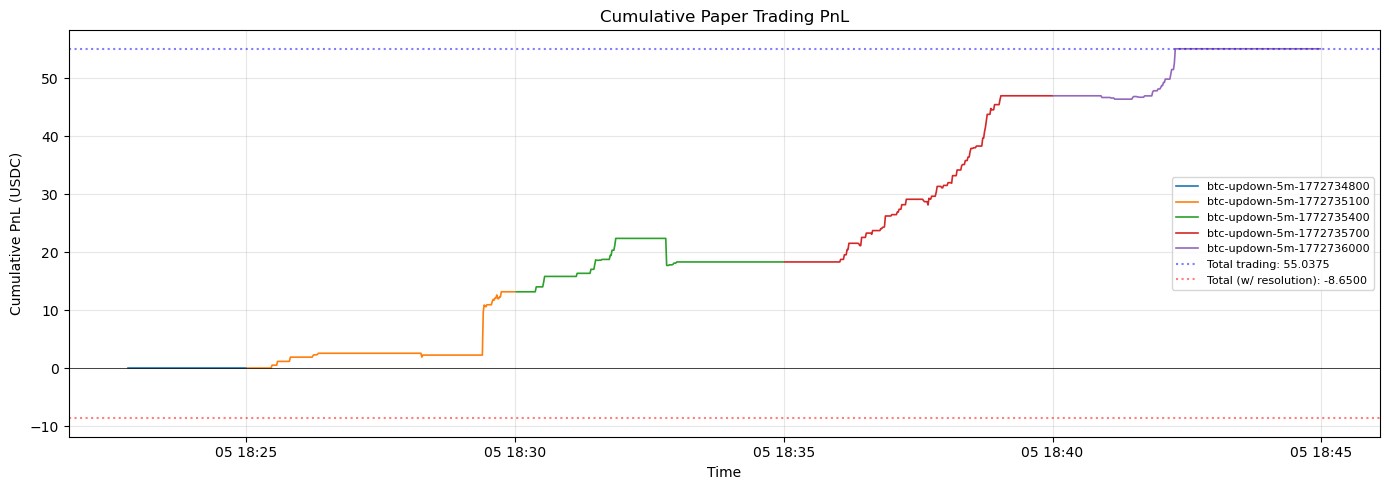

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

# Plot cumulative PnL from the tick-level log
for slug in slugs:
    t = ticks[ticks["market_slug"] == slug]
    pnl = pd.to_numeric(t["cumulative_pnl"], errors="coerce")
    ax.plot(t["dt"], pnl, lw=1.2, label=slug)

# Add resolution PnL as step changes at each market close
if len(results) > 0:
    cum_trading = 0.0
    cum_total = 0.0
    for r in results:
        cum_trading += r["trading_pnl"]
        cum_total += r["total_pnl"]

    ax.axhline(cum_trading, color="blue", ls=":", alpha=0.5, label=f"Total trading: {cum_trading:.4f}")
    ax.axhline(cum_total, color="red", ls=":", alpha=0.5, label=f"Total (w/ resolution): {cum_total:.4f}")

ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL (USDC)")
ax.set_title("Cumulative Paper Trading PnL")
ax.legend(fontsize=8)
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## 7. Fill Realism Check

Our paper trader uses optimistic fills (BUY fills instantly if bid >= best ask). In reality:
- Our order joins the queue; it doesn't get filled unless someone lifts our offer
- Large orders may only partially fill
- Latency means the book may have moved by the time our order arrives

This section estimates how many of our fills were **aggressive** (crossing the spread, likely real)
vs **passive** (resting at or inside the spread, optimistic assumption).

In [8]:
if len(fills) > 0:
    # Match each fill back to its PLACE event to see original order price
    places_indexed = places.set_index("order_id")

    realism = []
    for _, fill in fills.iterrows():
        oid = fill["order_id"]
        if oid not in places_indexed.index:
            continue
        place = places_indexed.loc[oid]
        order_price = place["price"]

        # Look at the book at fill time from ticks
        slug = fill["market_slug"]
        t = ticks[(ticks["market_slug"] == slug)].copy()
        t["time_diff"] = abs(t["timestamp"] - fill["timestamp"])
        nearest = t.nsmallest(1, "time_diff").iloc[0] if len(t) > 0 else None

        is_up = fill["token_label"] == "Up"
        if nearest is not None:
            book_bid = nearest["up_best_bid"] if is_up else nearest["down_best_bid"]
            book_ask = nearest["up_best_ask"] if is_up else nearest["down_best_ask"]
        else:
            book_bid = book_ask = np.nan

        # Aggressive: BUY at or above ask, SELL at or below bid
        if fill["side"] == "BUY":
            aggressive = bool(order_price >= book_ask) if pd.notna(book_ask) else np.nan
        else:
            aggressive = bool(order_price <= book_bid) if pd.notna(book_bid) else np.nan

        realism.append({
            "order_id": oid,
            "token": fill["token_label"],
            "side": fill["side"],
            "order_price": order_price,
            "fill_price": fill["fill_price"],
            "book_bid": book_bid,
            "book_ask": book_ask,
            "aggressive": aggressive,
        })

    realism_df = pd.DataFrame(realism)

    if len(realism_df) > 0:
        # Separate known from unknown
        known = realism_df["aggressive"].dropna()
        n_aggressive = int(known.sum())
        n_passive = int((~known.astype(bool)).sum())
        n_unknown = int(realism_df["aggressive"].isna().sum())

        print(f"Aggressive fills (crossing spread, likely real): {n_aggressive}")
        print(f"Passive fills (resting, optimistic assumption):  {n_passive}")
        print(f"Unknown (no book data):                         {n_unknown}")
        n_classifiable = n_aggressive + n_passive
        print(f"\nFill realism rate: {n_aggressive / max(n_classifiable, 1) * 100:.0f}%")
        print()
        display(realism_df)
    else:
        print("Could not match fills to placements.")
else:
    print("No fills to analyze.")

Aggressive fills (crossing spread, likely real): 218
Passive fills (resting, optimistic assumption):  160
Unknown (no book data):                         0

Fill realism rate: 58%



,order_id,token,side,order_price,fill_price,book_bid,book_ask,aggressive
0,paper-2,Down,BUY,0.43,0.43,0.17,0.18,True
1,paper-4,Down,BUY,0.42,0.42,0.17,0.18,True
2,paper-7,Down,BUY,0.41,0.41,0.17,0.18,True
3,paper-9,Down,BUY,0.40,0.40,0.17,0.18,True
4,paper-12,Down,BUY,0.39,0.39,0.17,0.18,True
...,...,...,...,...,...,...,...,...
373,paper-3440,Up,SELL,0.88,0.88,0.88,0.89,True
374,paper-3437,Down,BUY,0.11,0.11,0.11,0.12,False
375,paper-3442,Up,SELL,0.89,0.89,0.88,0.89,False
376,paper-3444,Up,SELL,0.91,0.91,0.88,0.89,False


## 8. Summary Statistics

In [9]:
print("=" * 60)
print("PAPER TRADING SESSION SUMMARY")
print("=" * 60)
print(f"Markets traded:           {len(markets)}")
print(f"Total tick snapshots:     {len(ticks):,}")
print(f"Total trade events:       {len(trades):,}")
print(f"  - Placements:           {len(places)}")
print(f"  - Fills:                {len(fills)}")
print(f"  - Cancellations:        {len(cancels)}")
print(f"  - Fill rate:            {len(fills) / max(len(places), 1) * 100:.1f}%")
print()

if len(fills) > 0 and "edge" in fills.columns:
    print(f"Mean edge at fill:        {fills['edge'].mean():.4f}")
    print(f"Median edge at fill:      {fills['edge'].median():.4f}")

if len(results_df) > 0:
    print()
    print(f"Trading PnL (spread):     {results_df['trading_pnl'].sum():.4f} USDC")
    print(f"Resolution PnL:           {results_df['resolution_pnl'].sum():.4f} USDC")
    print(f"TOTAL PnL:                {results_df['total_pnl'].sum():.4f} USDC")
    print(f"PnL per market:           {results_df['total_pnl'].mean():.4f} USDC")

    resolved = results_df[results_df["winner"] != "pending"]
    if len(resolved) > 0:
        winners = resolved[resolved["resolution_pnl"] > 0]
        print(f"\nResolution win rate:      {len(winners)}/{len(resolved)} ({len(winners)/len(resolved)*100:.0f}%)")

print()
print("NOTE: Fill simulation is optimistic. Multiply fill count by")
print("the fill realism rate (section 7) for a conservative estimate.")
print("=" * 60)

PAPER TRADING SESSION SUMMARY
Markets traded:           5
Total tick snapshots:     1,304
Total trade events:       7,247
  - Placements:           3702
  - Fills:                378
  - Cancellations:        3167
  - Fill rate:            10.2%

Mean edge at fill:        0.0146
Median edge at fill:      0.0128

Trading PnL (spread):     55.0375 USDC
Resolution PnL:           -63.6875 USDC
TOTAL PnL:                -8.6500 USDC
PnL per market:           -1.7300 USDC

Resolution win rate:      0/5 (0%)

NOTE: Fill simulation is optimistic. Multiply fill count by
the fill realism rate (section 7) for a conservative estimate.
